# Testing the UNet Model

In [1]:
import numpy as np
import os
import tifffile

from diet4cola.model.tracking import load_unet_model, get_motion_fields
from diet4cola.utils import *

In [2]:
experiment = '220530-E1_Out'

# Reading in the image from the associated experiment
image_dir = '../data/tiff'
image_file = [f for f in os.listdir(image_dir) if experiment in f and f.endswith('.tiff')] # type: ignore
if len(image_file) > 1:
    raise ValueError(f'Expected only one image for experiment {experiment}, but found {len(image_file)}')

image = tifffile.TiffFile(f'{image_dir}/{image_file[0]}')
image_data = np.squeeze(image.asarray())

# Preparation for visual plotting
channel_red     = image_data[0]                     # shape -> (115, 512, 512)
channel_green   = image_data[1]                     # shape -> (115, 512, 512)
channel_blue    = np.zeros(channel_green.shape)     # shape -> (115, 512, 512)

# Normalize for visualization 
channel_red_norm    = (channel_red - channel_red.min()) / (channel_red.max() - channel_red.min()) 
channel_green_norm  = (channel_green - channel_green.min()) / (channel_green.max() - channel_green.min())

# Create RG(B) stack for each slice
rgb_stack = np.zeros((115, 512, 512, 3), dtype=np.float32)
rgb_stack[..., 0] = channel_red_norm    # Red -> Myosin
rgb_stack[..., 1] = channel_green_norm  # Green -> Actin
rgb_stack[..., 2] = channel_blue        # Blue

In [3]:
gs_stack = image_data[0] + image_data[1]
gs_stack = (gs_stack - np.min(gs_stack)) / (np.max(gs_stack) - np.min(gs_stack))

In [4]:
model = load_unet_model('2s4VCjz6GJ6fqwNukQwdF5')

In [5]:
velocity_fields = get_motion_fields(gs_stack, model)

Processing...: 100%|██████████| 114/114 [00:27<00:00,  4.13it/s]


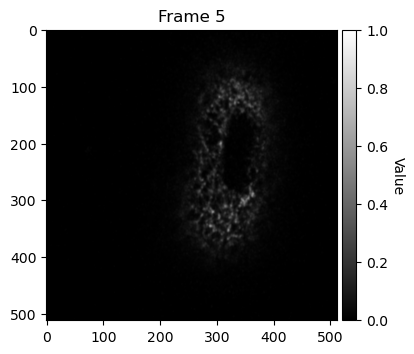

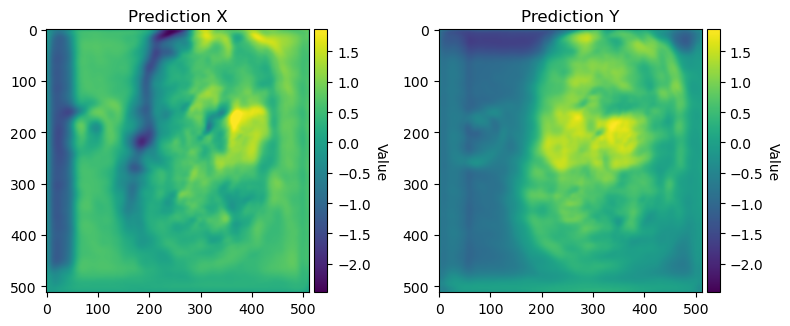

In [9]:
i = 5

vf_x = velocity_fields[i, 0]
vf_y = velocity_fields[i, 1]

vf_min = min(np.min(vf_x), np.min(vf_y))
vf_max = min(np.max(vf_x), np.max(vf_y))

plot_2d_array(gs_stack[i], f'Frame {i}', 'gray')
plot_2d_array_comparison(vf_x, vf_y, 'Prediction X', 'Prediction Y', 'viridis', vf_min, vf_max)